In [4]:
%load_ext autoreload
%autoreload 2
from braincoder.hrf import SPMHRFModel
from braincoder.models import * # GaussianPRF2DWithHRF, DifferenceOfGaussiansPRF2DWithHRF, DivisiveNormalizationGaussianPRF2DWithHRF, 

from braincoder.utils.data import load_szinte2024
from braincoder.optimize import ParameterFitter

import numpy as np

data = load_szinte2024()
paradigm = data['stimulus']
grid_coordinates = data['grid_coordinates']
train_data = data['v1_timeseries'].iloc[:, :200]
train_data.index.name = 'frame'
TR = data['tr']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data

{'stimulus': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        ...,
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0

In [6]:
hrf_model = SPMHRFModel(tr=TR)
from braincoder.hrf import SPMHRFDerivativeModel
# hrf_model = SPMHRFDerivativeModel(tr=TR)
positive_amplitude = True

debug = False

if debug:
    min_n_iterations = 10
    max_n_iterations = 100
    train_data = train_data.iloc[:, :5]
else:
    min_n_iterations = 100
    max_n_iterations = 1000


grid_parameters = {'x':np.linspace(-5, 5, 10),
                   'y':np.linspace(-5, 5, 10),
                   'size':np.linspace(1, 3, 10)}

model_gauss = GaussianPRF2DWithHRF(data=train_data,
                                    paradigm=paradigm,
                                    hrf_model=hrf_model,
                                    grid_coordinates=grid_coordinates)
par_fitter = ParameterFitter(model=model_gauss, data=train_data, paradigm=paradigm)
baseline = [0.0]
amplitude = [1.0]
pars_gauss_grid = par_fitter.fit_grid(grid_parameters['x'],
                                        grid_parameters['y'],
                                        grid_parameters['size'],
                                        baseline,
                                        amplitude,
                                        correlation_cost=True)
pars_gauss_ols = par_fitter.refine_baseline_and_amplitude(pars_gauss_grid,
                                                            positive_amplitude=positive_amplitude)
pars_gauss_gd = par_fitter.fit(init_pars=pars_gauss_ols,
                                min_n_iterations=min_n_iterations,
                                max_n_iterations=max_n_iterations)


Working with chunk size of 22222


2026-03-10 12:08:18.841809: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-10 12:08:18.841841: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-10 12:08:18.841848: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-10 12:08:18.841880: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-10 12:08:18.841891: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
Number of problematic voxels (mask): 3
Number of voxels remaining (mask): 197


Current R2: 0.23909/Best R2: 0.23909: 100%|██████████| 1000/1000 [00:21<00:00, 45.56it/s]


In [7]:
hrf_model = SPMHRFModel(tr=TR)
model_hrf = GaussianPRF2DWithHRF(data=train_data,
                                    paradigm=paradigm,
                                    hrf_model=hrf_model,
                                    grid_coordinates=grid_coordinates,
                                    flexible_hrf_parameters=True)

par_fitter_hrf = ParameterFitter(model=model_hrf, data=train_data, paradigm=paradigm)

# We set hrf_delay and hrf_dispersion to standard values
pars_gauss_gd['hrf_delay'] = 6
pars_gauss_gd['hrf_dispersion'] = 1

pars_gauss_hrf = par_fitter_hrf.fit(init_pars=pars_gauss_gd,
                                    min_n_iterations=min_n_iterations,
                                    max_n_iterations=max_n_iterations)
pars_gauss_hrf['r2'] = par_fitter_hrf.get_rsq(pars_gauss_hrf)


*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 3
Number of voxels remaining (mask): 197


  0%|          | 0/1000 [00:00<?, ?it/s]

(1, 150, 200) (24, 200)


Current R2: 0.39983/Best R2: 0.39984: 100%|██████████| 1000/1000 [00:28<00:00, 34.56it/s]


In [9]:
from braincoder.models import *
css_model = CompressiveSpatialGaussiansPRF2DWithHRF(
    data=train_data,
                                                     paradigm=paradigm,
                                                     hrf_model=hrf_model,
                                                     grid_coordinates=grid_coordinates,
                                                     flexible_hrf_parameters=True)


print(css_model.parameter_labels)

css_init_pars = pars_gauss_hrf.copy()

css_init_pars['exponent'] = 1.0

css_init_pars = css_init_pars.astype(np.float32)[css_model.parameter_labels]


['x', 'y', 'sd', 'baseline', 'amplitude', 'exponent', 'hrf_delay', 'hrf_dispersion']


In [10]:

css_fitter = ParameterFitter(model=css_model, data=train_data, paradigm=paradigm)
css_pars = css_fitter.fit(
    init_pars=css_init_pars, min_n_iterations=min_n_iterations, max_n_iterations=max_n_iterations,
    )

*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * exponent
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 3
Number of voxels remaining (mask): 197


Current R2: nan/Best R2: 0.40811: 100%|██████████| 1000/1000 [00:31<00:00, 32.10it/s] 


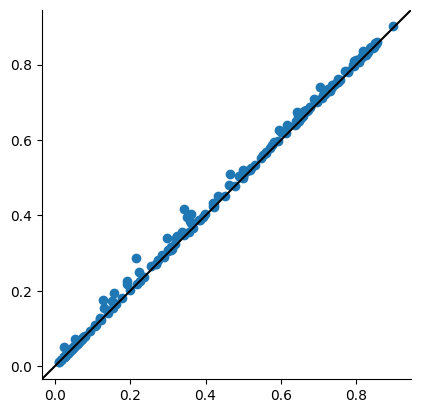

In [12]:
css_r2 = css_fitter.get_rsq(css_pars)
gauss_r2 = par_fitter_hrf.get_rsq(pars_gauss_hrf)
from dpu_mini.plot_functions import *
dag_scatter(
    gauss_r2, css_r2, do_id_line=True, 
)

parameter,x,y,sd,baseline,amplitude,exponent,hrf_delay,hrf_dispersion
source,,,,,,,,
0,4.497385,-1.887107,0.961378,-0.215720,2.513246,0.946145,3.002995,0.300564
1,4.760543,-2.299779,1.286311,-0.156239,0.557012,1.399431,3.002828,0.300515
2,5.667486,-2.302107,1.940371,-0.277985,0.096093,2.334867,3.003556,0.300714
3,6.118617,-2.678399,1.798608,-0.193731,0.086965,2.271668,3.004186,0.300769
4,7.073372,-2.424175,0.818761,-0.231708,7.063560,0.486540,3.002758,0.300525
...,...,...,...,...,...,...,...,...
195,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
197,2.350539,-0.062933,2.203240,-0.071992,0.320097,0.973016,3.009743,1.991491


In [50]:

model_dog = DifferenceOfGaussiansPRF2DWithHRF(data=train_data,
                                                paradigm=paradigm,
                                                hrf_model=hrf_model,
                                                grid_coordinates=grid_coordinates,
                                                flexible_hrf_parameters=True)

pars_dog_init = pars_gauss_hrf.copy()
pars_dog_init['amplitude'] = np.clip(pars_dog_init['amplitude'], 1e-4, None)
# This is the relative amplitude of the inhibitory receptive field
# compared to the excitatory one.
pars_dog_init['srf_amplitude'] = 0.0001
# pars_dog_init['srf_amplitude'] = 0.1*pars_dog_init['amplitude']

# This is the relative size of the inhibitory receptive field
# compared to the excitatory one.
pars_dog_init['srf_size'] = 4.
pars_dog_init = pars_dog_init.drop(columns=['r2'])

# Let's set up a new parameterfitter
par_fitter_dog = ParameterFitter(model=model_dog, data=train_data, paradigm=paradigm)
# pars_dog_init = par_fitter_dog.refine_baseline_and_amplitude(parameters=pars_dog_init,)
# # Note how, for now, we are not optimizing the HRF parameters.
pars_dog_hrf = par_fitter_dog.fit(init_pars=pars_dog_init,
                                min_n_iterations=min_n_iterations,
                                max_n_iterations=max_n_iterations, learning_rate=0.1)

*** Fitting: ***
 * x
 * y
 * sd
 * baseline
 * amplitude
 * srf_amplitude
 * srf_size
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 57
Number of voxels remaining (mask): 2308


  0%|          | 0/1000 [00:00<?, ?it/s]

(1, 2365, 9) (1, 2365, 5)


Current R2: 0.34366/Best R2: 0.35578: 100%|██████████| 1000/1000 [01:31<00:00, 10.90it/s]


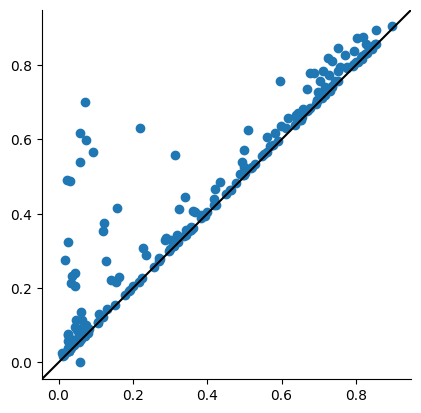

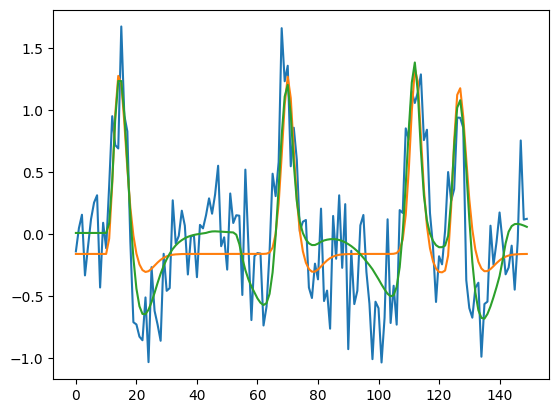

In [31]:
from dpu_mini.plot_functions import *
pred_g = par_fitter_hrf.get_predictions(parameters=pars_gauss_hrf)
pred_dog = par_fitter_dog.get_predictions(parameters=pars_dog_hrf)
r2_dog = par_fitter_dog.get_rsq(pars_dog_hrf)
r2_gauss = par_fitter_hrf.get_rsq(pars_gauss_hrf)
r2_css = css_fitter.get_rsq(css_pars)
ivx = np.where((r2_dog - r2_gauss)>0.1)[0][0]
# ivx = np.where((r2_gauss - r2_dog)>0.1)[0][0]
dag_scatter(
    r2_gauss, r2_dog, do_id_line=True, 
)
plt.figure()
plt.plot(train_data.iloc[:,ivx], label='data')
plt.plot(pred_g.iloc[:,ivx], label='gauss')
plt.plot(pred_dog.iloc[:,ivx], label='dog')

8

In [51]:
dn_model = DivisiveNormalizationGaussianPRF2DWithHRF(data=train_data,
                                                     paradigm=paradigm,
                                                     hrf_model=hrf_model,
                                                     grid_coordinates=grid_coordinates,
                                                     flexible_hrf_parameters=True)

dn_model.parameter_labels

dn_init_pars = pars_dog_hrf.copy().rename(columns={'amplitude':'rf_amplitude'})

dn_init_pars['neural_baseline'] = 0.1
dn_init_pars['surround_baseline'] = 0.1
dn_init_pars['bold_baseline'] = 0.0

dn_init_pars = dn_init_pars.astype(np.float32)[dn_model.parameter_labels]

dn_fitter = ParameterFitter(model=dn_model, data=train_data, paradigm=paradigm)

dn_pars = dn_fitter.fit(init_pars=dn_init_pars, min_n_iterations=min_n_iterations, max_n_iterations=max_n_iterations, learning_rate=0.1)

*** Fitting: ***
 * x
 * y
 * sd
 * rf_amplitude
 * srf_amplitude
 * srf_size
 * neural_baseline
 * surround_baseline
 * bold_baseline
 * hrf_delay
 * hrf_dispersion
Number of problematic voxels (mask): 57
Number of voxels remaining (mask): 2308


Current R2: 0.36125/Best R2: 0.36832: 100%|██████████| 1000/1000 [01:41<00:00,  9.83it/s] 
/Users/marcusdaghlian/programs/braincoder_bprf/braincoder/models.py:1909: RuntimeWarning: invalid value encountered in divide
  pre_convolve = pre_convolve - (neural_baseline / surround_baseline)


/Users/marcusdaghlian/programs/braincoder_bprf/braincoder/models.py:1909: RuntimeWarning: invalid value encountered in divide
  pre_convolve = pre_convolve - (neural_baseline / surround_baseline)
/Users/marcusdaghlian/programs/braincoder_bprf/braincoder/models.py:1909: RuntimeWarning: invalid value encountered in divide
  pre_convolve = pre_convolve - (neural_baseline / surround_baseline)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_466/3091506881.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


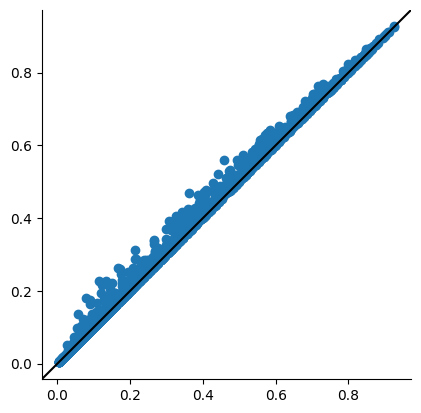

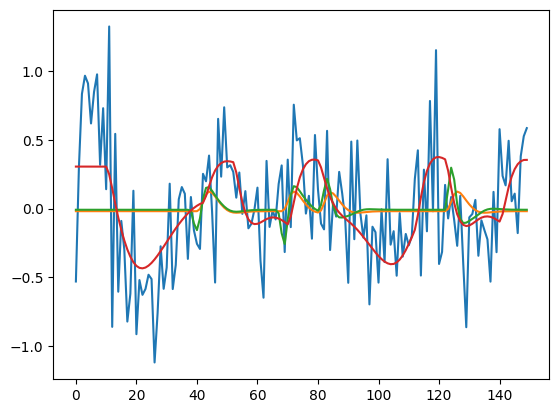

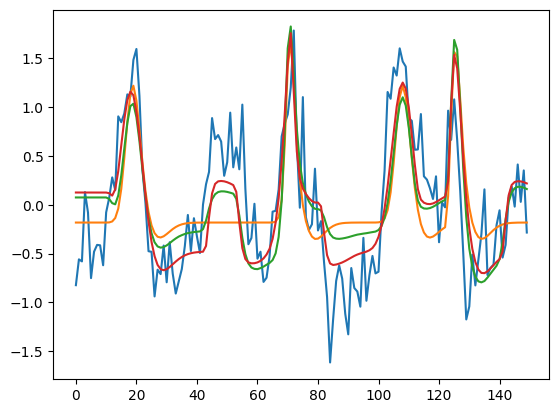

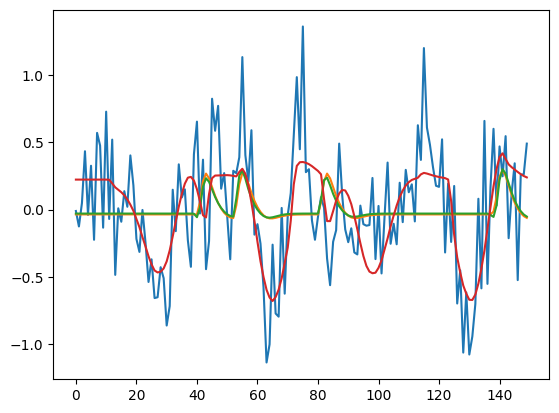

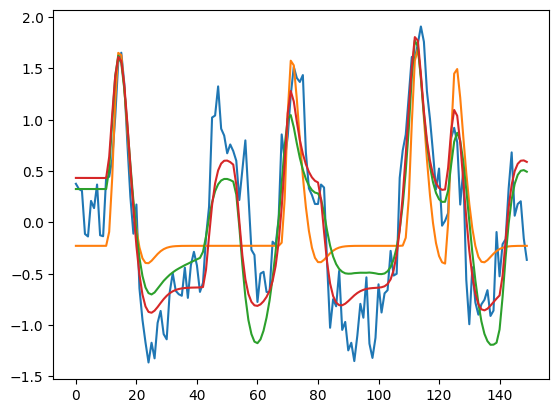

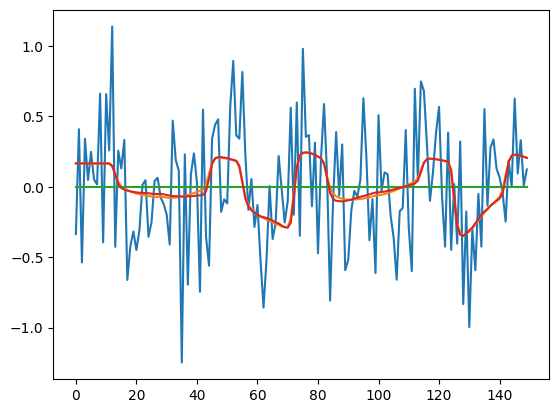

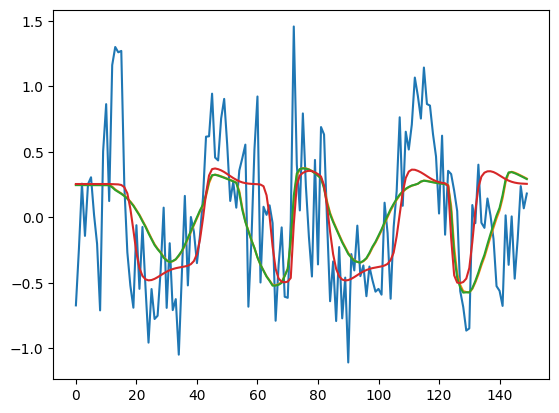

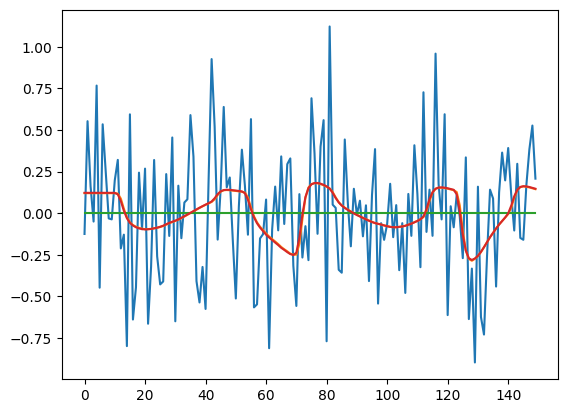

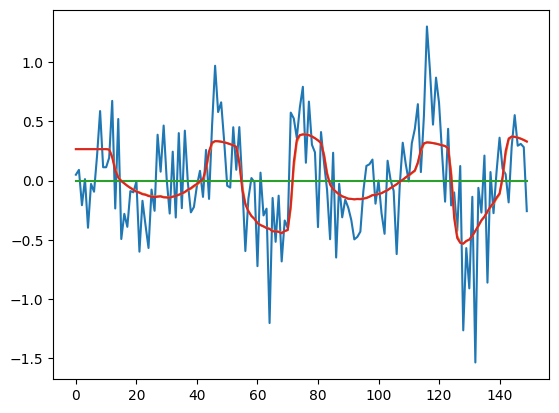

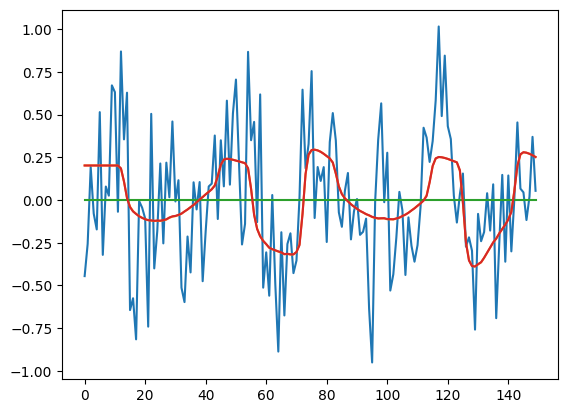

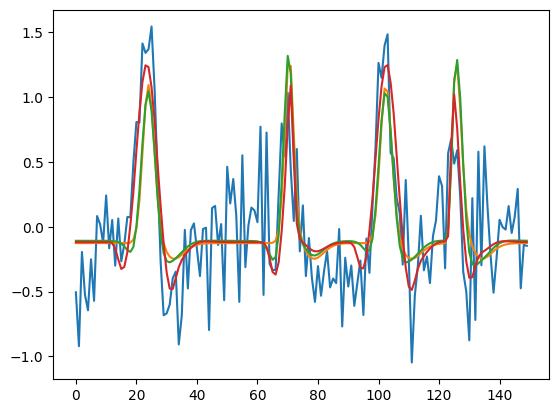

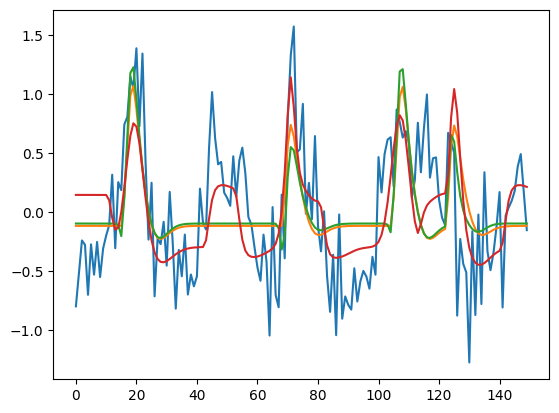

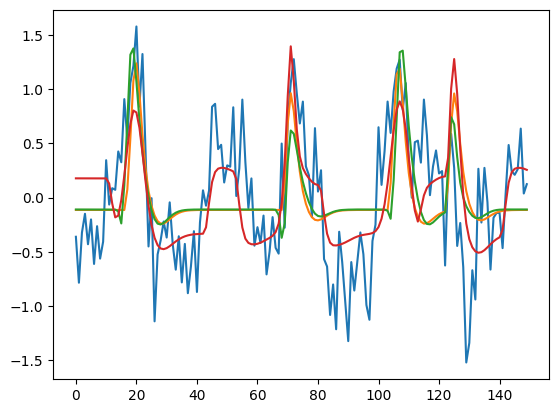

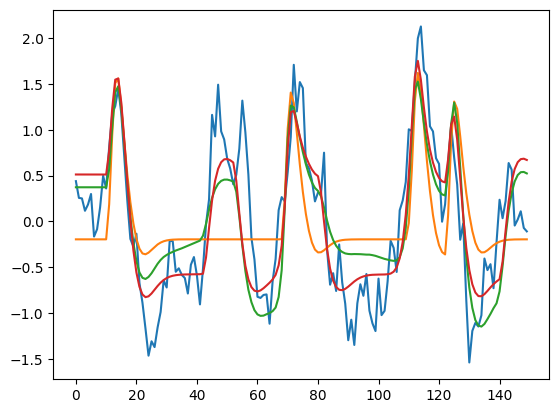

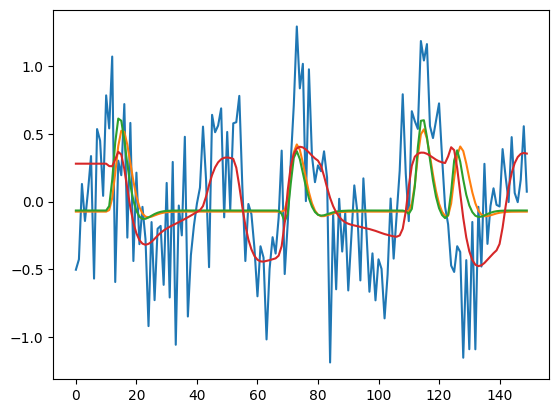

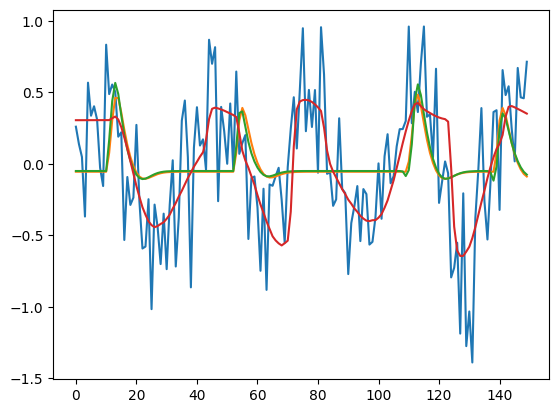

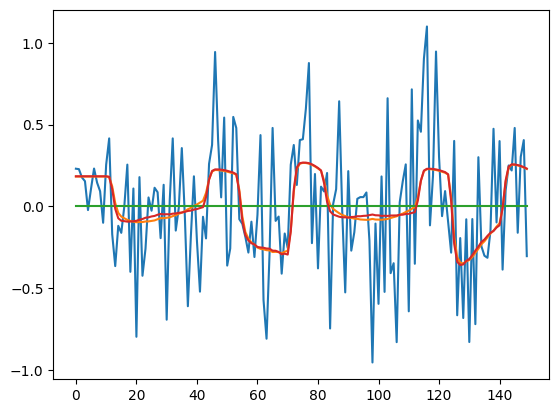

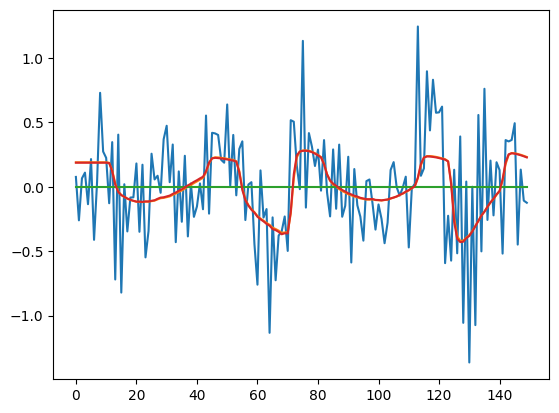

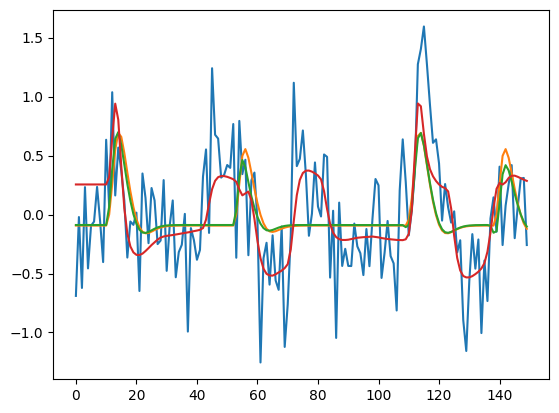

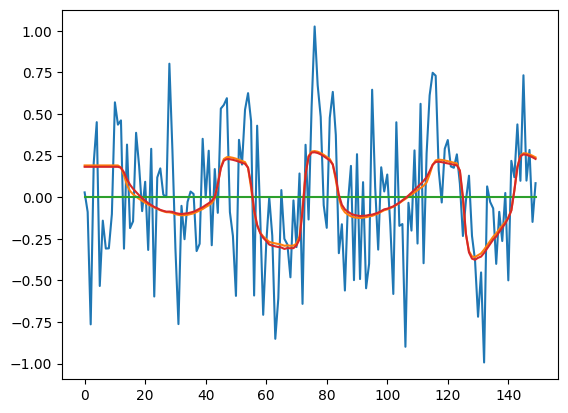

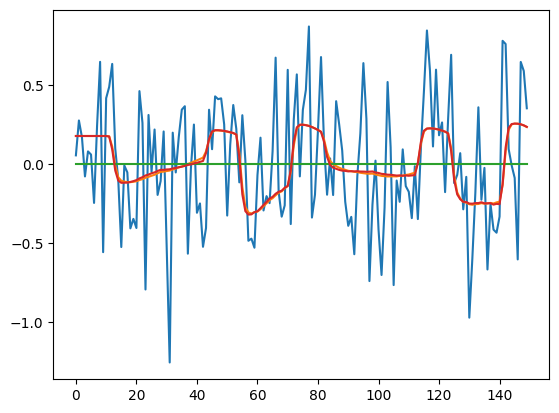

In [69]:
from dpu_mini.plot_functions import *
pred_g = par_fitter_hrf.get_predictions(parameters=pars_gauss_hrf)
pred_dog = par_fitter_dog.get_predictions(parameters=pars_dog_hrf)
pred_dn = dn_fitter.get_predictions(parameters=dn_pars)
pred_css = css_fitter.get_predictions(parameters=css_pars)
r2_dog = par_fitter_dog.get_rsq(pars_dog_hrf)
r2_gauss = par_fitter_hrf.get_rsq(pars_gauss_hrf)
r2_dn = dn_fitter.get_rsq(dn_pars)
r2_css = css_fitter.get_rsq(css_pars)
ivx = np.where((r2_dn - r2_dog)>0.1)[0][20:40]
# ivx = np.where((r2_gauss - r2_dog)>0.1)[0][0]
dag_scatter(
    r2_gauss, r2_css, do_id_line=True, 
)
for ivx_ in ivx:
    plt.figure()
    plt.plot(train_data.iloc[:,ivx_], label='data')
    plt.plot(pred_g.iloc[:,ivx_], label='gauss')
    plt.plot(pred_dog.iloc[:,ivx_], label='dog')
    plt.plot(pred_dn.iloc[:,ivx_], label='dn')

(array([ 75.,  15.,  13.,  21.,  28.,  51.,  57.,  62.,  62.,  78.,  80.,
         67.,  50.,  49.,  43.,  44.,  43.,  44.,  55., 819.,  45.,  34.,
         30.,  27.,  28.,  23.,  25.,  23.,  26.,  11.,  17.,  12.,  11.,
         18.,  10.,  15.,  12.,   6.,  16.,   8.,   5.,  12.,   8.,   7.,
         10.,  12.,   9.,  10.,   5.,   9.,   5.,   6.,   6.,   3.,   6.,
          5.,   6.,   3.,   8.,   6.,   5.,   3.,   5.,   3.,   1.,   4.,
          1.,   1.,   2.,   1.,   0.,   1.,   2.,   1.,   4.,   0.,   0.,
          1.,   2.,   0.,   0.,   3.,   0.,   1.,   0.,   2.,   2.,   0.,
          0.,   2.,   2.,   0.,   0.,   1.,   0.,   1.,   1.,   1.,   0.]),
 array([0.        , 0.05050505, 0.1010101 , 0.15151515, 0.2020202 ,
        0.25252525, 0.3030303 , 0.35353535, 0.4040404 , 0.45454545,
        0.50505051, 0.55555556, 0.60606061, 0.65656566, 0.70707071,
        0.75757576, 0.80808081, 0.85858586, 0.90909091, 0.95959596,
        1.01010101, 1.06060606, 1.11111111, 1.16161616, 1.21

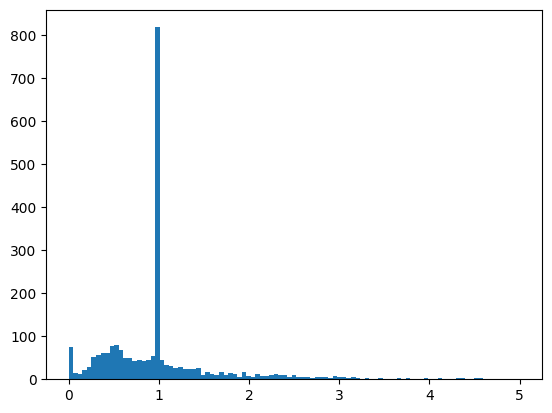

In [71]:
plt.hist(css_pars['exponent'], bins=np.linspace(0,5,100))

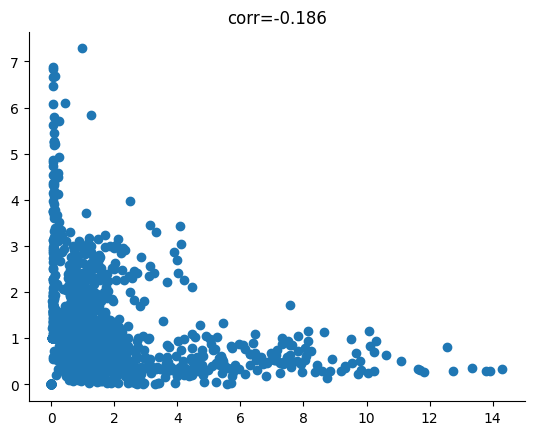

In [68]:
dag_scatter(
    pars_gauss_hrf['sd'], 
    css_pars['exponent'],
    do_corr=True,
    )

In [12]:
dn_init_pars

parameter,x,y,sd,rf_amplitude,srf_amplitude,srf_size,neural_baseline,surround_baseline,bold_baseline,hrf_delay,hrf_dispersion
source,,,,,,,,,,,
0,4.497403,-1.887147,0.993020,2.198391,0.000018,1.686040,0.1,0.1,0.0,3.002996,0.300564
1,4.762045,-2.295911,1.060046,1.495162,0.000016,1.684259,0.1,0.1,0.0,3.002832,0.300517
2,5.677525,-2.282188,1.224717,2.334288,0.000014,1.544388,0.1,0.1,0.0,3.003582,0.300720
3,6.123884,-2.652442,1.141682,1.763799,0.000021,1.709580,0.1,0.1,0.0,3.004251,0.300787
4,7.076703,-2.428593,1.228752,2.045971,0.000019,1.464739,0.1,0.1,0.0,3.002764,0.300535
...,...,...,...,...,...,...,...,...,...,...,...
195,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.1,0.1,0.0,0.000000,0.000000
196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.1,0.1,0.0,0.000000,0.000000
197,2.891629,-0.008267,4.146197,0.628617,0.350870,10.845592,0.1,0.1,0.0,4.362042,1.997548


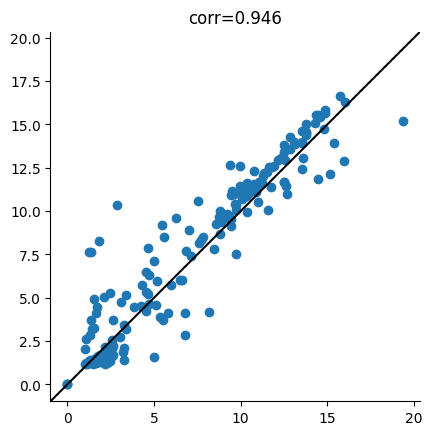

In [11]:
from dpu_mini.plot_functions import *
dag_scatter(
    dn_pars['srf_size'], 
    pars_dog_hrf['srf_size'], 
    do_id_line=True, 
    do_corr=True, 
)